<a href="https://colab.research.google.com/github/ThAlvesM/Kmean_2026-1/blob/Test%2FNovo_dataset/Kmean_2026-1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

----------------------------------------
# Seção 1: Introdução
----------------------------------------

##Contextualização
O K-means, por ser um algoritmo de clustering, é extremamente útil para identificação de padrões. Nesse sentido, focaremos no seguinte problema de negócio:

Uma determinada loja possui dados sobre seus clientes e pretende desenvolver um trabalho de análise de dados para compreender melhor o comportamento e características de cada perfil de cliente. A loja pretende promover promoções, descontos e ações publicitárias para fortalecer as vendas de produtos específicos, identificar quais produtos e setores da loja são mais frequentados por determinados perfis de clientes e criar estratégias de mercado para engajar grupos de clientes específicos.

##Objetivo
Buscamos responder a seguinte pergunta:
**Quais são os principais perfis/segmentos de clientes da loja com base em seu comportamento de compra, renda e características demográficas?**

##Descrição dos Dados
O Dataset escolhido é o "Shop Customer Data", oriundo do Kaggle. Os Dados de clientes da loja são uma análise detalhada do perfil ideal de clientes de uma loja. Eles ajudam a empresa a entender melhor seus clientes. O dono da loja obtém informações sobre os clientes por meio de cartões de fidelidade. Em relação ao significado de cada coluna do Dataset, o seguinte dicionário traz uma boa descrição:
* Customer ID (int)

ID único que identifica cada cliente da loja
* Gender (str)

Gênero do cliente
* Age (int)

Idade do cliente
* Annual Income (int)

Renda anual do cliente em dolares
* Spending Score (int)

pontuação dada ao cliente baseada em seu comportamento de compra e gastos
* Profession (str)

Ocupação profissional do cliente
* Work Experience (int)

Anos de experiência profissional do cliente
* Family Size (int)

Quantidade de membros da família do cliente


-----------------------------------------------
#Seção 2: Análise Exploratória de Dados (EDA)
-----------------------------------------------
● 2.1. Carregamento e Limpeza dos Dados: Importe os dados e mostre os primeiros
passos de verificação (ex: .info(), .describe(), .isnull().sum()). Descreva como tratou
dados faltantes, duplicados ou inconsistentes.

● 2.2. Análise Univariada: Explore as variáveis individualmente. Use gráficos
(histogramas, boxplots, etc) e métricas para entender a distribuição e as características
de cada variável relevante. Comente suas observações.

● 2.3. Análise Bivariada e Multivariada: Investigue a relação entre as variáveis. Use
gráficos (scatter plots, heatmaps de correlação) e tabelas para identificar padrões,
tendências e correlações.

● 2.4. Insights da Eda: Faça um resumo do que você aprendeu nesta fase. A análise
confirmou sua hipótese inicial? Surgiram novas perguntas? Quais variáveis parecem
ser mais promissoras para a modelagem?

In [2]:
install.packages("GGally")
library(GGally)
library(ggplot2)
library(tidyr)
library(dplyr)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘patchwork’, ‘ggstats’


Loading required package: ggplot2


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
install.packages("fastDummies")
library(fastDummies)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [4]:
dataset <- read.csv ("Train.csv", header = TRUE)
#Fazer alguma verificação aqui no meio
print("Dataset Instalado com Sucesso")

[1] "Dataset Instalado com Sucesso"


In [6]:
summary(dataset)

       ID               Gender        Ever_Married       Age       
 Min.   :458982   Length   :8068   Length   :8068   Min.   :18.00  
 1st Qu.:461241   N.unique :   2   N.unique :   3   1st Qu.:30.00  
 Median :463472   N.blank  :   0   N.blank  : 140   Median :40.00  
 Mean   :463479   Min.nchar:   4   Min.nchar:   0   Mean   :43.47  
 3rd Qu.:465744   Max.nchar:   6   Max.nchar:   3   3rd Qu.:53.00  
 Max.   :467974                                     Max.   :89.00  
                                                                   
     Graduated        Profession   Work_Experience    Spending_Score
 Length   :8068   Length   :8068   Min.   : 0.000   Length   :8068  
 N.unique :   3   N.unique :  10   1st Qu.: 0.000   N.unique :   3  
 N.blank  :  78   N.blank  : 124   Median : 1.000   N.blank  :   0  
 Min.nchar:   0   Min.nchar:   0   Mean   : 2.642   Min.nchar:   3  
 Max.nchar:   3   Max.nchar:  13   3rd Qu.: 4.000   Max.nchar:   7  
                                   Max.   

In [16]:
info_colun_num <- function(c){
  cat("Tipo:", typeof(c), "| NAs:", sum(is.na(c) | c == ""), "| Únicos:", n_distinct(c), "\n")
  cat(paste("5 primeiros elementos:",
  c[1], " - ", c[2], " - ",c[3], " - ",c[4], " - ",c[5], "\n"))

  c_filtrado <- c[c != "" & !is.na(c)]

  if (is.numeric(c)) {
    cat(paste("Mínimo:", round(min(c_filtrado), 2), "\t"))
    cat(paste("1ºQuart:", round(quantile(c_filtrado, probs = 0.25), 2), "\t"))
    cat(paste("Média:", round(mean(c_filtrado),2), "\t"))
    cat(paste("3ºQuart:", round(quantile(c_filtrado, probs = 0.75), 2), "\t"))
    cat(paste("Máximo:", round(max(c_filtrado), 2), "\n"))
    cat(paste("Desvio Padrão:", round(sd(c_filtrado), 2),"\t"))
    cat(paste("Mediana", round(median(c_filtrado), 2),"\n"))

  } else {
      cat(paste("Máximo caracteres:", max(nchar(c_filtrado)), "\t"))
      cat(paste("Mínimo caracteres:", min(nchar(c_filtrado)), "\n"))

      tab_abs <- table(c)
      names(dimnames(tab_abs)) <- "Frequncia Absoluta"
      print(tab_abs)


      tab_rel <- prop.table(table(c)) * 100
      names(dimnames(tab_rel)) <- "Frequencia Relativa"
      print(tab_rel)

  }
}

In [17]:
#Coluna Id
cat("Id\n")
info_colun_num(dataset$ID)
cat("-------------------------------------------------\n")
#Coluna Genero
cat("Gender\n")
info_colun_num(dataset$Gender)
cat("-------------------------------------------------\n")
#Coluna Status Matrial
cat("Ever_Married\n")
info_colun_num(dataset$Ever_Married)
cat("-------------------------------------------------\n")
#Coluna Idade
cat("Age\n")
info_colun_num(dataset$Age)
cat("-------------------------------------------------\n")
#Coluna Graduação
cat("Graduated\n")
info_colun_num(dataset$Graduated)
cat("-------------------------------------------------\n")
#Coluna Profissao
cat("Profession\n")
info_colun_num(dataset$Profession)
cat("-------------------------------------------------\n")
#Coluna Experiencia de Trabalho
cat("Work_Experience\n")
info_colun_num(dataset$Work_Experience)
cat("-------------------------------------------------\n")
#Coluna Score de Gasto
cat("Spending_Score\n")
info_colun_num(dataset$Spending_Score)
cat("-------------------------------------------------\n")
#Coluna Familiares
cat("Family_Size\n")
info_colun_num(dataset$Family_Size)
cat("-------------------------------------------------\n")
#Coluna Var 1?
cat("Var_1\n")
info_colun_num(dataset$Var_1)
cat("-------------------------------------------------\n")
#Coluna Segmentation?
cat("Segmentation\n")
info_colun_num(dataset$Segmentation)
cat("-------------------------------------------------\n")

Id
Tipo: integer | NAs: 0 | Únicos: 8068 
5 primeiros elementos: 462809  -  462643  -  466315  -  461735  -  462669 
Mínimo: 458982 	1ºQuart: 461240.75 	Média: 463479.21 	3ºQuart: 465744.25 	Máximo: 467974 
Desvio Padrão: 2595.38 	Mediana 463472.5 
-------------------------------------------------
Gender
Tipo: character | NAs: 0 | Únicos: 2 
5 primeiros elementos: Male  -  Female  -  Female  -  Male  -  Female 
Máximo caracteres: 6 	Mínimo caracteres: 4 
Frequncia Absoluta
Female   Male 
  3651   4417 
Frequencia Relativa
  Female     Male 
45.25285 54.74715 
-------------------------------------------------
Ever_Married
Tipo: character | NAs: 140 | Únicos: 3 
5 primeiros elementos: No  -  Yes  -  Yes  -  Yes  -  Yes 
Máximo caracteres: 3 	Mínimo caracteres: 2 
Frequncia Absoluta
       No  Yes 
 140 3285 4643 
Frequencia Relativa
               No      Yes 
 1.73525 40.71641 57.54834 
-------------------------------------------------
Age
Tipo: integer | NAs: 0 | Únicos: 67 
5 primeiro

Warning message:
“Removed 1164 rows containing non-finite outside the scale range
(`stat_boxplot()`).”
Warning message:
“Removed 1164 rows containing non-finite outside the scale range (`stat_bin()`).”


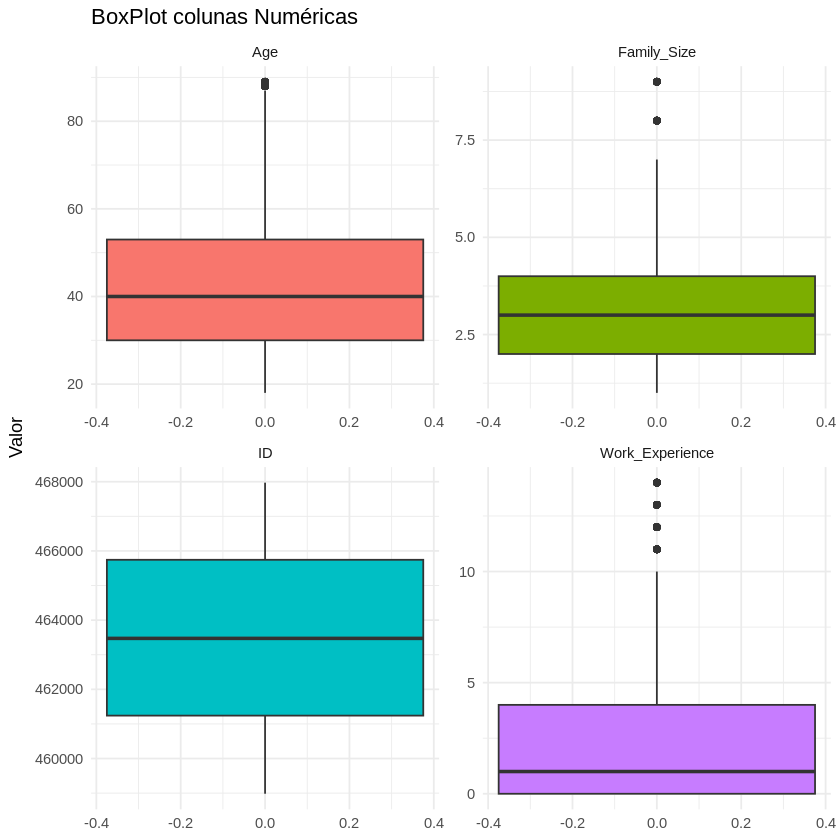

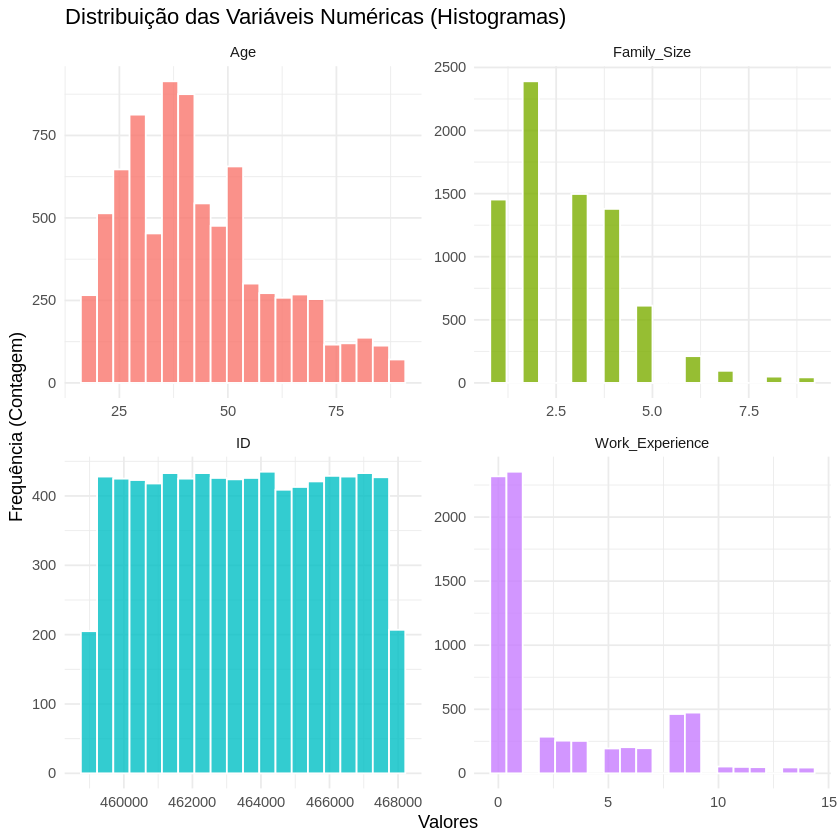

In [18]:
dados_longo <- dataset %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(y = Valor, fill = Variavel)) +
  geom_boxplot() +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(title = "BoxPlot colunas Numéricas")

dados_longo <- dataset %>%
  select(where(is.numeric)) %>%
  pivot_longer(cols = everything(), names_to = "Variavel", values_to = "Valor")

ggplot(dados_longo, aes(x = Valor, fill = Variavel)) +
  geom_histogram(bins = 20, color = "white", alpha = 0.8) +
  facet_wrap(~Variavel, scales = "free") +
  theme_minimal() +
  theme(legend.position = "none") +
  labs(
    title = "Distribuição das Variáveis Numéricas (Histogramas)",
    x = "Valores",
    y = "Frequência (Contagem)"
  )

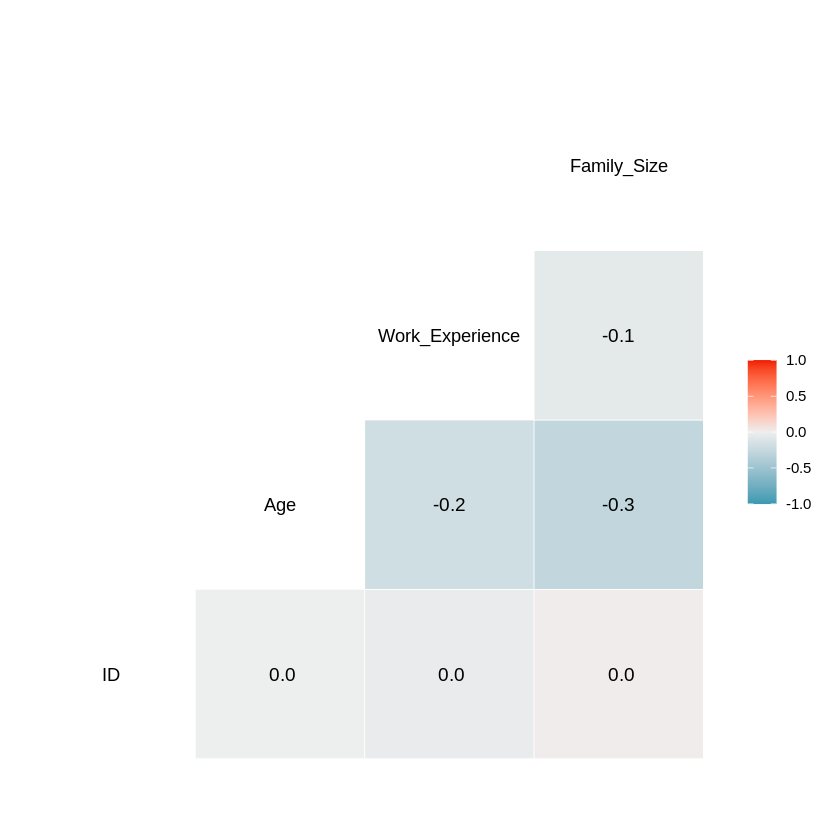

In [19]:
dataset_numerico <- dataset[, sapply(dataset, is.numeric)]
ggcorr(dataset_numerico, label=T)

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


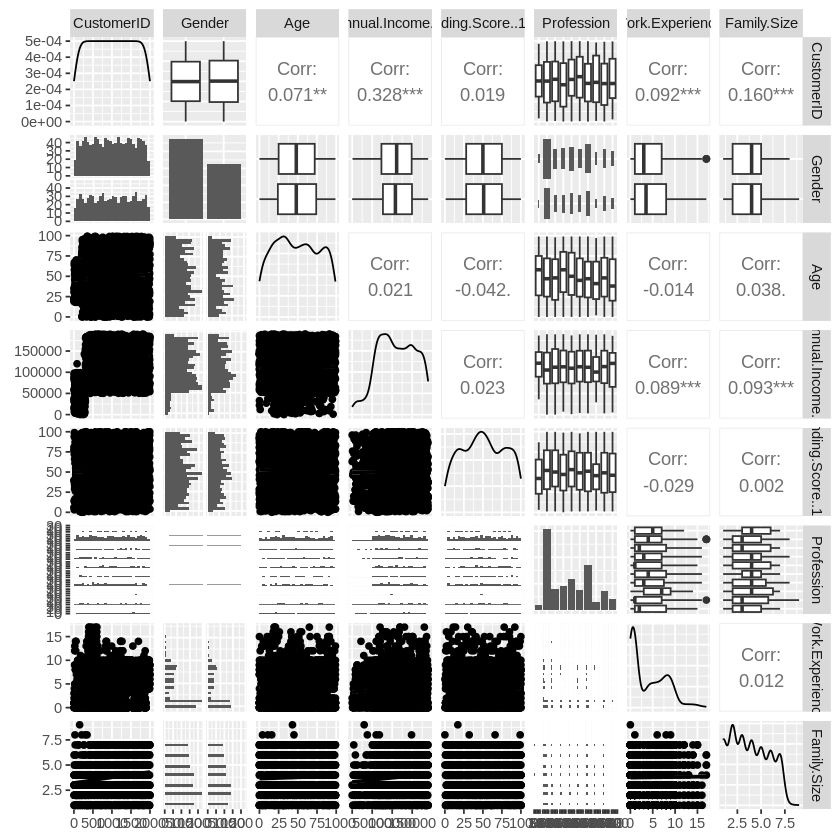

In [ ]:
ggpairs(dataset, lower = list(continuous = "smooth"))

In [ ]:
cat("Total de linhas duplicadas no dataset:", sum(duplicated(dataset)), "\n")
cat("Total de Ids duplicados no dataset:", sum(duplicated(dataset$CustomerID)))

Total de linhas duplicadas no dataset: 0 
Total de Ids duplicados no dataset: 0

In [ ]:
dataset$Profession[dataset$Profession == ""] <- "Sem Profissão"
#maiores de 18 anos
dataset_18 <- dataset[which(dataset$Age >= 18), ]
cat("Outliers removidos:", nrow(dataset) - nrow(dataset_18), "linhas.\n")
#idade minima pela lei
dataset_filtrado <- dataset_18[which((dataset_18$Age - dataset_18$Work.Experience) >= 14), ]
cat("Outliers removidos:", nrow(dataset_18) - nrow(dataset_filtrado), "linhas.\n")

Outliers removidos: 332 linhas.
Outliers removidos: 375 linhas.


In [ ]:
summary(dataset_filtrado)

-----------------------------------------------
#Seção 3: Validação Estatística (Teste de Hipóteses)
-----------------------------------------------
● 3.1. Definição das Hipóteses: Declare formalmente a Hipótese Nula e a Hipótese
Alternativa. As hipóteses devem estar relacionadas aos padrões identificados na EDA.

● 3.2. Escolha a Execução do Teste: Utilize o teste adequado para o seu tema (Teste t,
ANOVA, Qui-quadrado, Teste de Correlação de Pearson, etc.).

● 3.3. Interpretação do p-valor: Com base em um nível de significância (ex: 5%),
determine se há evidências para rejeitar a hipótese nula e valide se o padrão encontrado
na EDA é estatisticamente significante.

-----------------------------------------------
#Seção 4: Pré-processamento e Aplicação da Técnica
-----------------------------------------------
● 4.1. Preparação dos Dados para o Modelo: Descreva e execute os passos necessários
para preparar os dados para a sua técnica específica (ex: normalização/padronização
para K-Means, criação de variáveis dummy para regressão, etc.).

● 4.2. Modelagem: Aplicação do algoritmo do seu tema. Explique a escolha de
parâmetros, se houver.

In [ ]:
dataset_preparado <- dummy_cols(
  dataset_filtrado,
  select_columns = c("Gender","Profession"),
  remove_selected_columns = TRUE
)

head(dataset_preparado)

dataset_final<- as.data.frame(scale(dataset_preparado))
head(dataset_final)

,CustomerID,Age,Annual.Income....,Spending.Score..1.100.,Work.Experience,Family.Size,Gender_Female,Gender_Male,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing,Profession_Sem Profissão
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,19,15000,39,1,4,0,1,0,0,0,0,0,1,0,0,0,0
2,2,21,35000,81,3,3,0,1,0,0,1,0,0,0,0,0,0,0
3,3,20,86000,6,1,1,1,0,0,0,1,0,0,0,0,0,0,0
4,4,23,59000,77,0,2,1,0,0,0,0,0,0,0,0,1,0,0
5,5,31,38000,40,2,6,1,0,0,0,0,1,0,0,0,0,0,0
6,6,22,58000,76,0,2,1,0,1,0,0,0,0,0,0,0,0,0


,CustomerID,Age,Annual.Income....,Spending.Score..1.100.,Work.Experience,Family.Size,Gender_Female,Gender_Male,Profession_Artist,Profession_Doctor,Profession_Engineer,Profession_Entertainment,Profession_Executive,Profession_Healthcare,Profession_Homemaker,Profession_Lawyer,Profession_Marketing,Profession_Sem Profissão
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-1.677798,-1.665890,-2.0291568,-0.4130691,-0.7581789,0.1233988,-1.2103534,1.2103534,-0.6635749,-0.2885863,-0.3246187,-0.3691608,-0.2860776,2.2149650,-0.1706295,-0.2758842,-0.2040613,-0.1347562
2,-1.676086,-1.580485,-1.5960573,1.1065497,-0.2296329,-0.3868381,-1.2103534,1.2103534,-0.6635749,-0.2885863,3.0786417,-0.3691608,-0.2860776,-0.4511966,-0.1706295,-0.2758842,-0.2040613,-0.1347562
3,-1.674374,-1.623187,-0.4916535,-1.6070553,-0.7581789,-1.4073120,0.8256966,-0.8256966,-0.6635749,-0.2885863,3.0786417,-0.3691608,-0.2860776,-0.4511966,-0.1706295,-0.2758842,-0.2040613,-0.1347562
4,-1.672662,-1.495081,-1.0763378,0.9618241,-1.0224518,-0.8970751,0.8256966,-0.8256966,-0.6635749,-0.2885863,-0.3246187,-0.3691608,-0.2860776,-0.4511966,-0.1706295,3.6224791,-0.2040613,-0.1347562
5,-1.670950,-1.153462,-1.5310923,-0.3768877,-0.4939059,1.1438728,0.8256966,-0.8256966,-0.6635749,-0.2885863,-0.3246187,2.7071794,-0.2860776,-0.4511966,-0.1706295,-0.2758842,-0.2040613,-0.1347562
6,-1.669238,-1.537783,-1.0979928,0.9256427,-1.0224518,-0.8970751,0.8256966,-0.8256966,1.5060614,-0.2885863,-0.3246187,-0.3691608,-0.2860776,-0.4511966,-0.1706295,-0.2758842,-0.2040613,-0.1347562


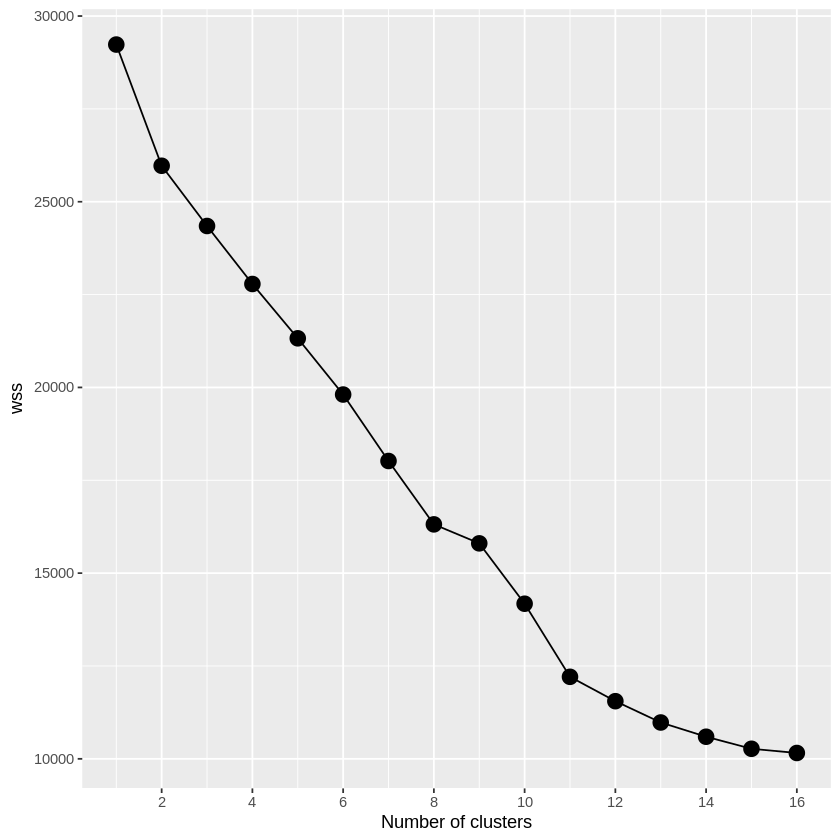

In [ ]:
n_clusters <- 16

wss <- numeric(n_clusters)

set.seed(123)

for (i in 1:n_clusters) {
  km.out <- kmeans(dataset_final, centers = i, nstart = 20)
  wss[i] <- km.out$tot.withinss
}

wss_df <- tibble(clusters = 1:n_clusters, wss = wss)

scree_plot <- ggplot(wss_df, aes(x = clusters, y = wss, group = 1)) +
    geom_point(size = 4)+
    geom_line() +
    scale_x_continuous(breaks = c(2, 4, 6, 8, 10, 12, 14, 16)) +
    xlab('Number of clusters')
scree_plot


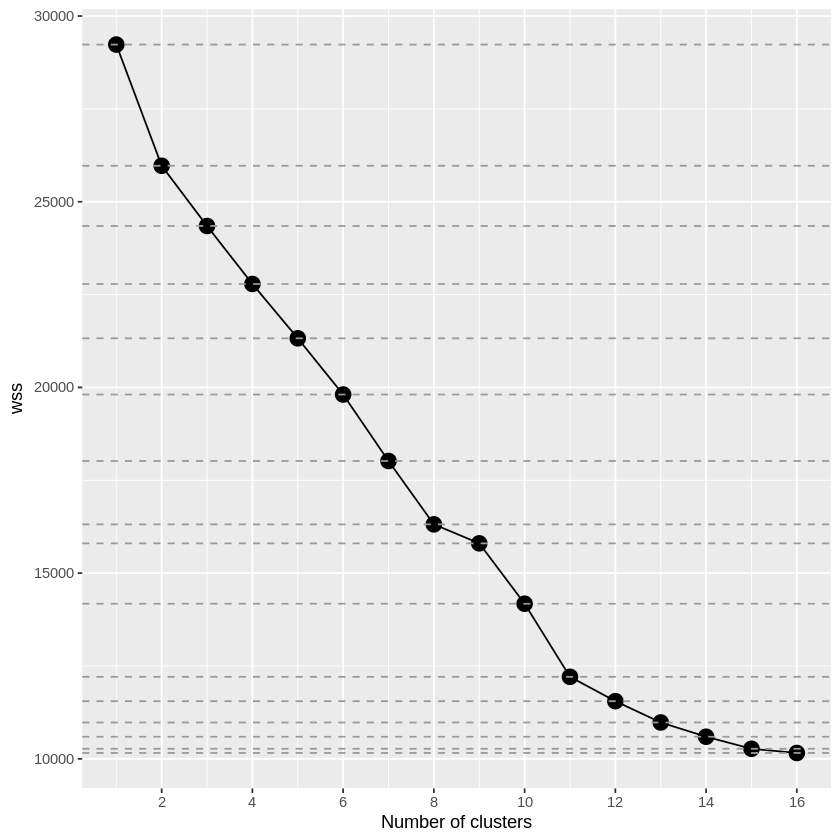

In [ ]:
scree_plot +
  geom_hline(
    yintercept = wss,
    linetype = 'dashed',
    color = 'gray60',
    linewidth = 0.5
  )

-----------------------------------------------
#Seção 5: Resultados e Interpretação
-----------------------------------------------
● 5.1. Apresentação dos Resultados: Mostre a saída do seu modelo de forma clara.
Pode ser uma tabela com coeficientes, uma visualização dos clusters, uma imagem da
árvore de decisão, etc.

● 5.2. Análise Crítica dos Resultados: Esta é a parte mais importante. Traduza a
saída técnica em uma explicação clara e objetiva.
  
○ Exemplo para K-Means: "O modelo identificou 3 clusters. O Cluster 1, que
chamamos de 'Clientes Econômicos', é caracterizado por... O Cluster 2,
'Clientes Premium', por sua vez..."
  
○ Exemplo para Regressão Linear: "O coeficiente para a variável 'área_m2' foi
de 850. Isso sugere que, mantendo as outras variáveis constantes, cada metro
quadrado adicional está associado a um aumento de R$850 no preço do
aluguel."

-----------------------------------------------
#Seção 6: Conclusão
-----------------------------------------------
● 6.1. Resumo dos Insights: Sintetize as principais descobertas do seu projeto.
Responda diretamente à pergunta que você se propôs a investigar na introdução.

● 6.2. Recomendações Práticas: Com base nos seus achados, o que você recomendaria
para uma empresa ou área de estudo? Proponha 1 ou 2 ações concretas.

● 6.3. Limitações e Próximos Passos: Nenhum projeto é perfeito. Discuta as limitações
da sua análise (ex: poucos dados, variáveis faltantes, simplicidade do modelo).